# Currents
13 Mar 2026

copy-paste of Vincent's `post-processing.ipynb`, but modified to be 1-click run and can change between output and archive directories.

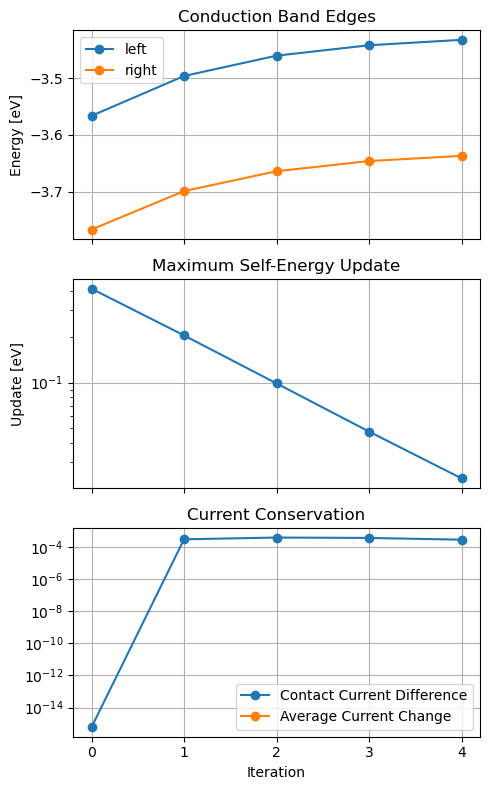

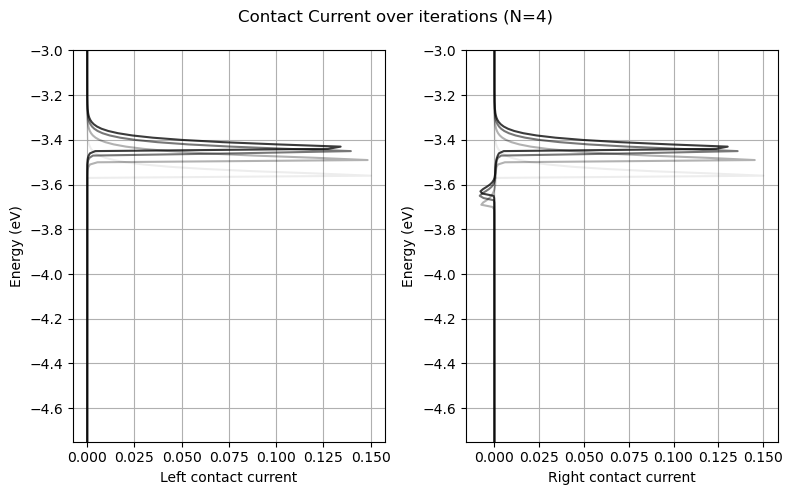

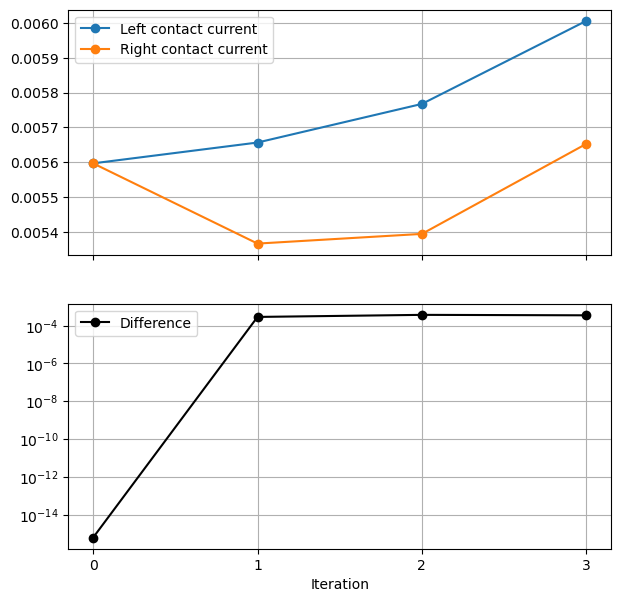

In [48]:
import glob
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from scipy.signal import find_peaks

from quatrex.core.config import parse_config
from quatrex.post_processing.plot_ldos import get_averages, spectral_plot

# band-limited study
# 20260226_152224_energy201_iter20_reduced
# 20260226_155038_energy2001_iter5_reduced
# 20260227_113823_energy20001_iter5_reduced

# adaptive and non-adaptive comparison
# 20260312_134438_energy2001_iter5_reduced                      # reference
# 20260312_133859_adaptive_iter1_energy2001_iter5_reduced
# 20260312_155421_adaptive_iter1_energy2001_iter5_reduced       # fixed energy range in polarization
# 20260312_171322_adaptive_iter1_energy2001_iter5_reduced       # fix v2, fixed error energy_max=energy_window_num, lots of singularities in g
# 20260313_092537_adaptive_iter1_r10_energy2001_iter5_reduced   # r=10 oversampling ratio (previous results r=1)
# 20260313_093014_adaptive_iter1_r0d5_energy2001_iter5_reduced  # r=0.5

data_files = 'archive'  # 'archive' or 'output'
archive_name = "20260312_134438_energy2001_iter5_reduced"

# region: === loading data ===
example_dir = Path("./../../examples/w90/carbon-nanotube/gw")
input_dir = example_dir / "inputs"

archive_dir = example_dir / "archive" / archive_name
output_dir = example_dir / "outputs"


if data_files == 'archive':
    data_dir = archive_dir
    config_dir = archive_dir
elif data_files == 'output':
    config_dir = example_dir 
    data_dir = output_dir

config = parse_config(config_dir / "quatrex_config.toml")

with open(config_dir / "out.txt") as f:
    out = f.readlines()

maximum_self_energy_updates = [
    float(line.split()[-1]) for line in out if "Maximum Self-Energy Update" in line
]
average_current_changes = [
    float(line.split()[-1]) for line in out if line.startswith("Average Current Change")
]
relative_average_current_changes = [
    float(line.split()[-1]) for line in out if "Relative Average Current Change" in line
]
current_differences = [
    float(line.split()[-1]) for line in out if "Current Difference" in line
]
relative_current_conservations = [
    float(line.split()[-1]) for line in out if "Relative Current Conservation" in line
]
right_conduction_band_edges = [
    float(line.split()[-1]) for line in out if "Updating conduction band" in line
]
left_conduction_band_edges = [
    float(line.split()[-2].strip(","))
    for line in out
    if "Updating conduction band" in line
]
iterations = [int(line.split()[-1]) for line in out if "Iteration" in line]
# endregion

# region: === plotting ===
plotCurrents = True
if plotCurrents:
    fig, (ax_band_edges, ax_self_energy, ax_current) = plt.subplots(
        3, 1, figsize=(5, 8), sharex=True, layout="tight"
    )
    ax_band_edges.plot(left_conduction_band_edges, marker="o", label="left")
    ax_band_edges.plot(right_conduction_band_edges, marker="o", label="right")
    ax_band_edges.legend()
    # ax_band_edges.set_yscale("log")
    ax_band_edges.set_ylabel("Energy [eV]")
    ax_band_edges.set_title("Conduction Band Edges")
    ax_band_edges.grid()

    ax_self_energy.plot(maximum_self_energy_updates, marker="o")
    ax_self_energy.set_yscale("log")
    ax_self_energy.set_ylabel("Update [eV]")
    ax_self_energy.set_title("Maximum Self-Energy Update")
    ax_self_energy.grid()

    ax_current.plot(
        np.abs(current_differences), label="Contact Current Difference", marker="o"
    )
    ax_current.plot(average_current_changes, label="Average Current Change", marker="o")
    ax_current.set_yscale("log")
    ax_current.set_title("Current Conservation")
    ax_current.legend()
    ax_current.set_xlabel("Iteration")
    ax_current.grid()
    ax_current.xaxis.set_major_locator(MaxNLocator(integer=True))


    plt.show()

plotFadingAlpha = True
if plotFadingAlpha:
    left_files = glob.glob(str(data_dir / "i_left_*.npy"))
    right_files = glob.glob(str(data_dir / "i_right_*.npy"))

    left_currents = np.array([np.load(f) for f in left_files[: iterations[-1]]])
    right_currents = np.array([np.load(f) for f in right_files[: iterations[-1]]])

    # energies = np.load(input_dir / "electron_energies.npy")
    energies = np.linspace(
        config.electron.energy_window_min,
        config.electron.energy_window_max,
        config.electron.energy_window_num,
    )

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 5), layout="tight")

    num_iterations = len(left_currents)

    for i, (left_current, right_current) in enumerate(zip(left_currents, right_currents)):
        ax_left.plot(
            -left_current.real, energies, "k", alpha=(i + 0.3) / (num_iterations + 0.3)
        )
        ax_right.plot(
            right_current.real, energies, "k", alpha=(i + 0.3) / (num_iterations + 0.3)
        )
        ax_left.set_ylim(-4.75, -3)
        ax_right.set_ylim(-4.75, -3)

    ax_left.set_xlabel("Left contact current")
    ax_right.set_xlabel("Right contact current")
    ax_left.set_ylabel("Energy (eV)")
    ax_right.set_ylabel("Energy (eV)")

    ax_left.grid()
    ax_right.grid()
    # ax_left.set_xscale("log")
    # ax_right.set_xscale("log")

    plt.suptitle(f"Contact Current over iterations (N={num_iterations})")
    plt.tight_layout()
    plt.show()

plotConvergence = True
if plotConvergence:
    fig, (ax_currents, ax_diff) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    dE = energies[1] - energies[0]
    ax_currents.plot(
        -left_currents.sum(1).real * dE,
        label="Left contact current",
        marker="o",
    )
    ax_currents.plot(
        right_currents.sum(1).real * dE,
        label="Right contact current",
        marker="o",
    )
    diff = left_currents.sum(1).real * dE + right_currents.sum(1).real * dE
    ax_diff.plot(np.abs(diff), label="Difference", color="k", marker="o")

    ax_currents.legend()
    ax_currents.grid()

    ax_diff.set_xlabel("Iteration")
    ax_diff.set_yscale("log")
    ax_diff.legend()
    ax_diff.grid()
    ax_diff.xaxis.set_major_locator(MaxNLocator(integer=True))


    plt.show()

plotLdosRightContact = False
if plotLdosRightContact:
    files = glob.glob(str(data_dir / "electron_ldos_*.npy"))
    # DOS of first layer.
    doss = np.array([np.load(f)[:, :32].mean(1) for f in files[: iterations[-1]]])
    band_gaps = []
    # Find peaks to determine band gaps.
    for i in range(doss.shape[0]):
        peaks = find_peaks(doss[i], height=0.001)[0]
        peak_energies = energies[peaks]
        mask = (peak_energies - config.electron.left_fermi_level) < 0
        band_gaps.append(np.abs(peak_energies[mask].max() - peak_energies[~mask].min()))


    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.plot(
        energies,
        doss[0],
        color="k",
        label="Initial",
    )
    ax.plot(
        energies,
        doss[-1],
        color="r",
        label="Converged",
    )
    # ax.set_xlim(-5.5, -2.5)
    # ax.set_ylim(-0.01, 0.1)
    ax.set_xlabel("Energy [eV]")
    ax.set_ylabel("DOS")
    ax.legend()
    ax.grid()

    # add a title
    ax.set_title("Local Density of States (LDOS)")

    plt.show()

# endregion

